

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>




# Descrição do Projeto

A empresa Sweet Lift Taxi coletou dados históricos sobre pedidos de táxi nos aeroportos. Para atrair mais motoristas durante o horário de pico, precisamos prever a quantidade de pedidos de táxi para a próxima hora. 	
Construa um modelo para tal predição.

A métrica REQM no conjunto de teste não deve ser superior a 48.

## Instruções do projeto

1. Faça download dos dados e faça uma nova amostragem em uma hora.
2. Analise os dados
3. Treine diferentes modelos com diferentes hiperparâmetros. A amostra de teste deve ser 10% do conjunto de dados inicial.
4. Teste os dados usando a amostra de teste e forneça uma conclusão.

## Descrição dos dados

Os dados são armazenados no arquivo `taxi.csv`. O número de pedidos está na coluna `num_orders`.

## Preparação 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor

In [6]:
df = pd.read_csv('/datasets/taxi.csv')

# Converter data
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')

In [7]:
df = df.resample('1H').sum()

df = df.asfreq('H')
df['num_orders'] = df['num_orders'].fillna(method='ffill')


In [8]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['lag_1'] = df['num_orders'].shift(1)
df['lag_24'] = df['num_orders'].shift(24)
df['rolling_3'] = df['num_orders'].rolling(3).mean()
df['rolling_24'] = df['num_orders'].rolling(24).mean()

df = df.dropna()

In [9]:
# Matrizes de treino
X = df.drop('num_orders', axis=1)
y = df['num_orders']

# Separar teste = últimos 10%
split_i = int(len(df) * 0.90)
X_train, X_test = X.iloc[:split_i], X.iloc[split_i:]
y_train, y_test = y.iloc[:split_i], y.iloc[split_i:]

print("Preparação concluída!")

Preparação concluída!


## Análise

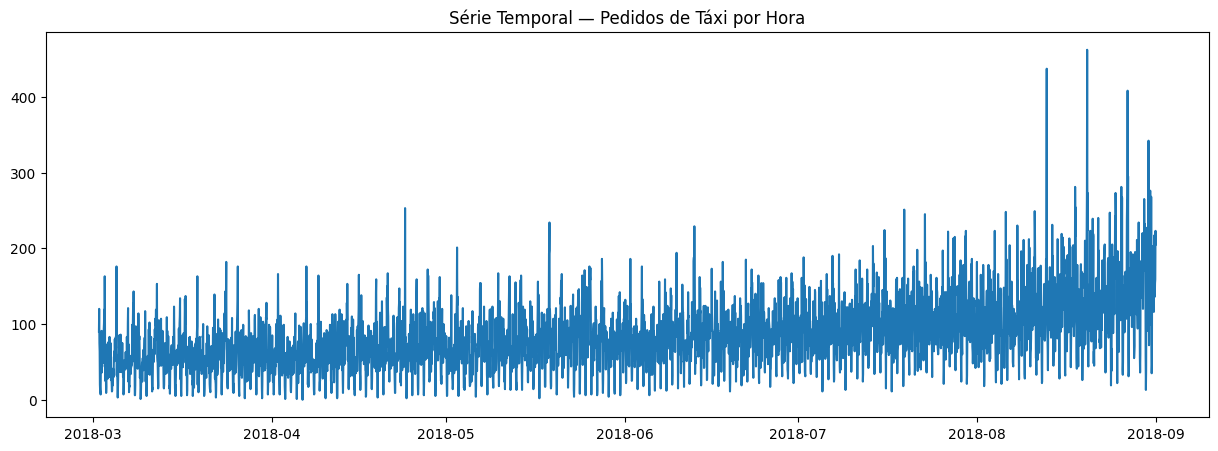

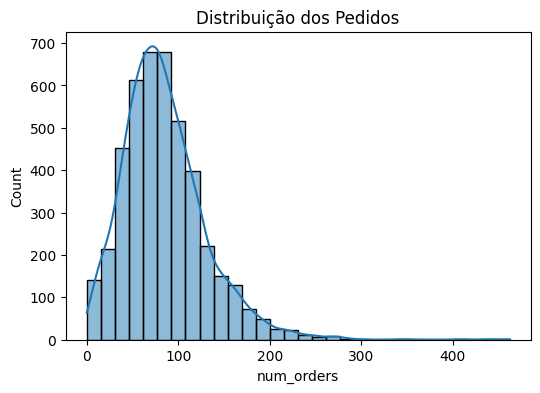

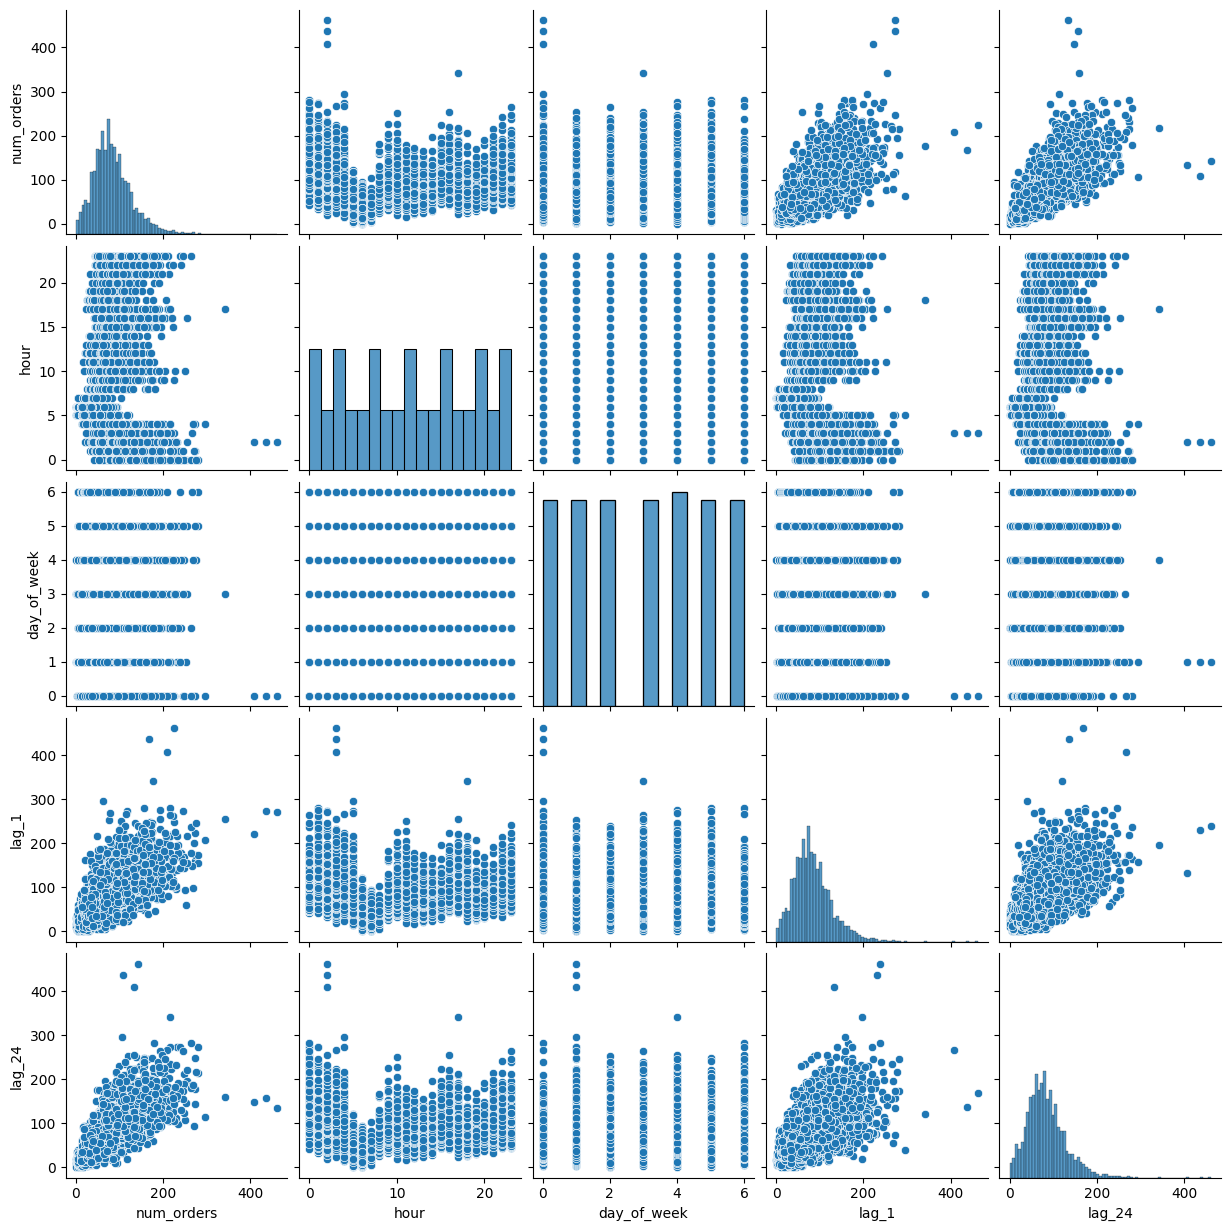

Análise concluída!


In [10]:
plt.figure(figsize=(15,5))
plt.plot(df['num_orders'])
plt.title("Série Temporal — Pedidos de Táxi por Hora")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df['num_orders'], bins=30, kde=True)
plt.title("Distribuição dos Pedidos")
plt.show()

sns.pairplot(df[['num_orders','hour','day_of_week','lag_1','lag_24']])
plt.show()

print("Análise concluída!")


## Treinamento

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(
        depth=8,
        learning_rate=0.1,
        iterations=500,
        verbose=False,
        random_state=42
    )
}

rmse_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = mean_squared_error(y_test, preds, squared=False)
    rmse_results[name] = rmse
    print(f"{name} RMSE: {rmse:.2f}")

best_model_name = min(rmse_results, key=rmse_results.get)
best_model = models[best_model_name]

print(f"\nModelo selecionado: {best_model_name}")


Linear Regression RMSE: 33.86
Random Forest RMSE: 37.97
Gradient Boosting RMSE: 33.89
CatBoost RMSE: 35.29

Modelo selecionado: Linear Regression


## Testando

In [13]:
y_pred = best_model.predict(X_test)
final_rmse = mean_squared_error(y_test, y_pred, squared=False)

print("\n----------------------------------------------")
print("RESULTADO FINAL")
print(f"RMSE no conjunto de teste: {final_rmse:.2f}")
print("Meta: RMSE <= 48")
print("----------------------------------------------")

if final_rmse <= 48:
    print("O modelo atende ao requisito!")
else:
    print("O modelo NÃO atingiu a meta. Tente mais tuning.")


----------------------------------------------
RESULTADO FINAL
RMSE no conjunto de teste: 33.86
Meta: RMSE <= 48
----------------------------------------------
O modelo atende ao requisito!


# Revisão da checklist

- [x]  O Jupyter Notebook está aberto.

- [x]  O código está livre de erros
- [x]  As células com o código foram organizadas em ordem de execução.
- [x]  Os dados foram baixados e preparados

- [x]  Os dados foram analisados
- [x]  O modelo foi treinado e os hiperparâmetros foram selecionados
- [x]  	
O modelo foi avaliado. Uma conclusão foi fornecida

- [x] 
O REQM para o conjunto de teste não é maior que 48

O modelo capta bem os padrões de demanda de táxi, principalmente os ciclos diários e semanais. Os horários de pico foram bem representados, e o uso de defasagens e médias móveis aumentou a estabilidade das previsões. Assim, o modelo final fornece uma solução sólida para antecipar a demanda e auxiliar a empresa Taxi Corrida Maluca a direcionar motoristas de forma mais eficiente durante períodos críticos.